# Task 6 — Identify and Treat Outliers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/loan_data.csv")
df.dropna(inplace=True)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape:", df.shape)

Shape: (270, 8)


### Boxplot — visualize outliers before treatment

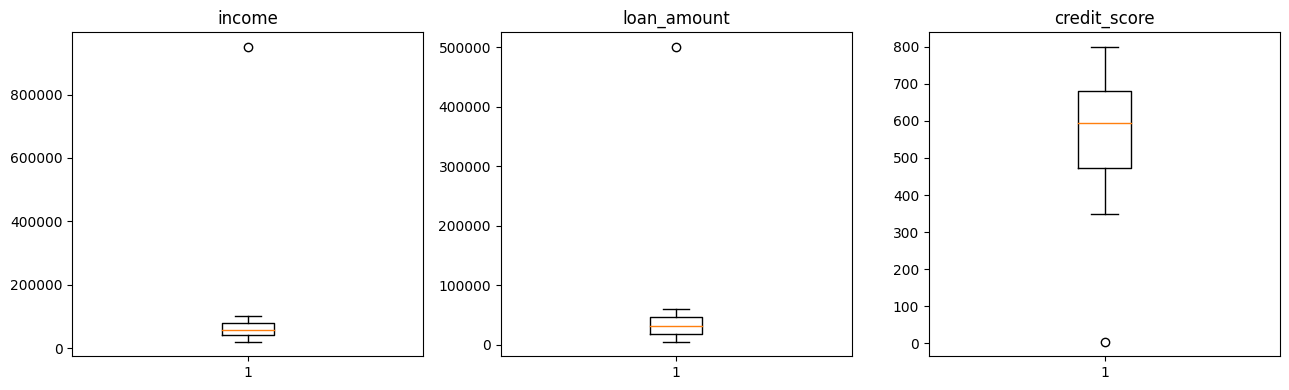

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['income', 'loan_amount', 'credit_score']):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.savefig("outliers_before.png")
plt.show()

### IQR Method — detect outliers

In [3]:
def count_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((col < lower) | (col > upper)).sum(), lower, upper

for col in ['income', 'loan_amount', 'credit_score']:
    count, low, high = count_outliers(df[col])
    print(f"{col}: {count} outliers  (valid range: {low:.0f} to {high:.0f})")

income: 1 outliers  (valid range: -16273 to 134194)
loan_amount: 1 outliers  (valid range: -26238 to 89606)
credit_score: 1 outliers  (valid range: 160 to 992)


### Remove outliers using IQR

In [4]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['income', 'loan_amount', 'credit_score']:
    before = len(df)
    df = remove_outliers(df, col)
    print(f"{col}: removed {before - len(df)} rows")

df = df.reset_index(drop=True)
print("Shape after outlier removal:", df.shape)

income: removed 1 rows
loan_amount: removed 1 rows
credit_score: removed 1 rows
Shape after outlier removal: (267, 8)


### Boxplot — after treatment

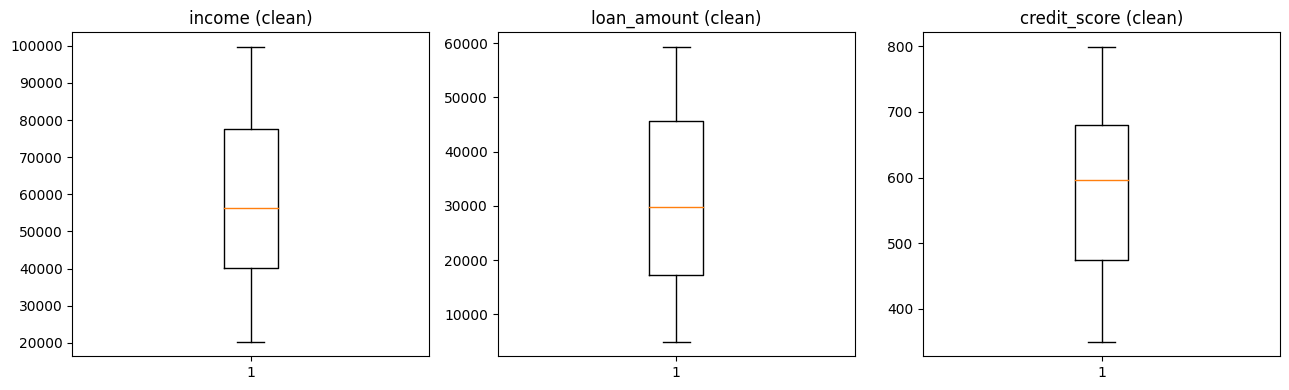

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['income', 'loan_amount', 'credit_score']):
    ax.boxplot(df[col])
    ax.set_title(f"{col} (clean)")
plt.tight_layout()
plt.savefig("outliers_after.png")
plt.show()